### Reinforcement Learning

Reference: https://www.geeksforgeeks.org/machine-learning/what-is-reinforcement-learning/


Reinforcement Learning (RL) is a type of machine learning where an agent learns to make decisions by interacting with an environment. The agent receives feedback in the form of rewards or penalties based on its actions, and its goal is to maximize the cumulative reward over time.

In RL, the agent learns a policy, which is a mapping from states of the environment to actions. The agent explores the environment and updates its policy based on the rewards received. This process is often modeled as a Markov Decision Process (MDP), which provides a mathematical framework for decision-making in situations where outcomes are partly random and partly under the control of the agent.

Suppose a maze game where an agent (like a robot) needs to find the exit. The agent can move in four directions: up, down, left, and right. Each time the agent takes a step, it receives a reward based on its action. For example, if the agent moves closer to the exit, it might receive a positive reward, while moving away from the exit might result in a negative reward. The agent's objective is to learn a policy that guides it to the exit in the most efficient way possible, maximizing its cumulative reward over time.

In DSA, we learn about the Backtracking algorithm, which is a general algorithm for finding all (or some) solutions to computational problems, notably constraint satisfaction problems. It incrementally builds candidates to the solutions and abandons a candidate ("backtracks") as soon as it determines that the candidate cannot possibly lead to a valid solution. This technique is often used in problems like Sudoku, N-Queens, and other combinatorial problems where the solution space is large.

In RL, we can use Q-tables to represent the value of taking a certain action in a given state. The agent updates the Q-values based on the rewards received from the environment, allowing it to learn the optimal policy over time. This process is known as Q-learning, which is a model-free reinforcement learning algorithm that seeks to find the best action to take given the current state of the environment.

Initiate the maze as matrix and the Q-table as a matrix of zeros. The agent will learn to navigate the maze by updating the Q-table based on the rewards received from taking actions in different states of the maze. The agent will explore the maze, receive rewards for moving closer to the exit, and update its policy accordingly to maximize its cumulative reward over time.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0, 0)
goal = (9, 9)

In this Q-table, each row represents a state of the maze, and each column represents an action (up, down, left, right). The values in the Q-table will be updated as the agent learns from its interactions with the environment, allowing it to make informed decisions about which actions to take in different states of the maze.

Other parameters such as `num_episodes`, `alpha`, `gamma`, `epsilon`, `reward_fire`, `reward_goal`, and `reward_step` will be defined to control the learning process of the agent. The `num_episodes` parameter determines how many times the agent will interact with the environment, while `alpha` (learning rate) and `gamma` (discount factor) control how the agent updates its Q-values based on new information. The `epsilon` parameter is used for epsilon-greedy action selection, which allows the agent to balance exploration and exploitation. The reward parameters define the rewards received for different actions, such as firing a weapon, reaching the goal, or taking a step in the maze.

The `actions` parameter will define the possible actions the agent can take in the maze, such as moving up, down, left, or right. The state parameter will represent the current state of the maze, which can be defined based on the agent's position and other relevant factors. The reward parameter will be used to calculate the rewards received by the agent based on its actions and the resulting state of the maze.

The agent will learn to navigate the maze by updating its Q-table based on the rewards received from taking actions in different states of the maze. The agent will explore the maze, receive rewards for moving closer to the exit, and update its policy accordingly to maximize its cumulative reward over time.


In [32]:
num_episodes = 5000
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

Define a helper Function for maze validity and action selection. This function will check if the agent's intended move is valid (i.e., it does not go out of bounds or into a wall) and will also implement the epsilon-greedy strategy for action selection, allowing the agent to explore the environment while also exploiting its learned knowledge to make informed decisions.

In [33]:
def is_valid(pos):
    r, c = pos
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True


def choose_action(state):
    if np.random.random() < epsilon:
        return np.random.randint(len(actions))
    else:
        return np.argmax(Q[state])

Train the Agent with a Reinforcement Learning Algorithm. Here, we choose Q-learning as our reinforcement learning algorithm. The agent will interact with the environment (the maze) for a specified number of episodes, updating its Q-table based on the rewards received from taking actions in different states of the maze. The agent will learn to navigate the maze by maximizing its cumulative reward over time, ultimately finding the optimal policy for reaching the exit efficiently.

The Q-Learning equation:

`Q(state, action) = Q(state, action) + alpha * (reward + gamma * max(Q(next_state)) - Q(state, action))`

Where:
- `Q(state, action)` is the current Q-value for the given state and action.
- `alpha` is the learning rate, which determines how much the Q-values are updated based on new information.
- `reward` is the immediate reward received after taking the action in the current state.
- `gamma` is the discount factor, which determines the importance of future rewards.
- `max(Q(next_state))` is the maximum Q-value for the next state, representing the best possible future reward from that state.

The agent will update its Q-table using the Q-learning equation after each action taken in the maze, allowing it to learn from its interactions with the environment and improve its policy over time. By maximizing its cumulative reward, the agent will eventually learn the optimal policy for navigating the maze and reaching the exit efficiently.

In [34]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state = start
    total_rewards = 0
    done = False

    while not done:
        action_index = choose_action(state)
        action = actions[action_index]

        next_state = (state[0] + action[0], state[1] + action[1])

        if not is_valid(next_state):
            reward = reward_fire
            done = True
        elif next_state == goal:
            reward = reward_goal
            done = True
        else:
            reward = reward_step

        old_value = Q[state][action_index]
        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0

        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)

        state = next_state
        total_rewards += reward

    global epsilon
    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards)

Extract the optimal path after training the agent. Once the agent has learned an optimal policy through Q-learning, we can extract the optimal path from the starting point to the exit by following the actions with the highest Q-values in each state. This involves starting from the initial state and repeatedly selecting the action with the highest Q-value until the exit is reached. The resulting sequence of states and actions will represent the optimal path through the maze, allowing us to visualize or analyze how the agent navigates to reach its goal efficiently.

In [35]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps):
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                    next_state not in visited):

                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path


optimal_path = get_optimal_path(Q, start, goal, actions, maze)

Visualize the Maze, Robot Path, Start and Goal. After extracting the optimal path, we can visualize the maze along with the robot's path from the starting point to the exit. This visualization can be done using libraries such as Matplotlib in Python, where we can represent the maze as a grid and highlight the path taken by the agent. The start and goal positions can be marked distinctly to clearly show the agent's journey through the maze. This visual representation will help us understand how the agent navigates the environment and reaches its goal efficiently.

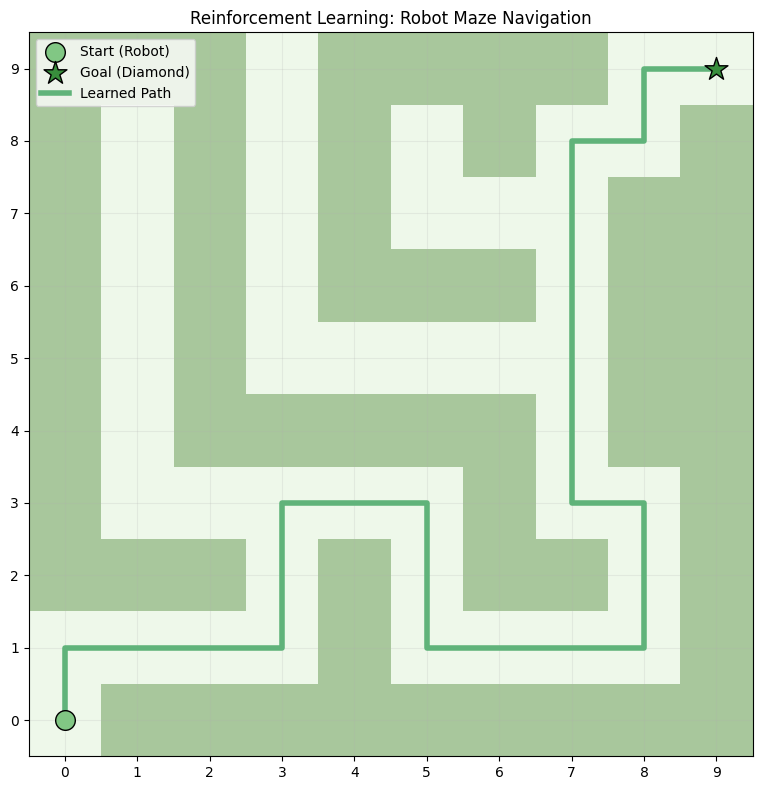

In [36]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_maze_with_path(optimal_path)

We can also plot the rewards received by the agent during training to visualize the learning progress. This can be done by keeping track of the rewards received in each episode and plotting them using Matplotlib. The plot will show how the rewards evolve over time, indicating whether the agent is learning to maximize its cumulative reward effectively. A rising trend in the rewards would suggest that the agent is improving its policy and learning to navigate the maze more efficiently.

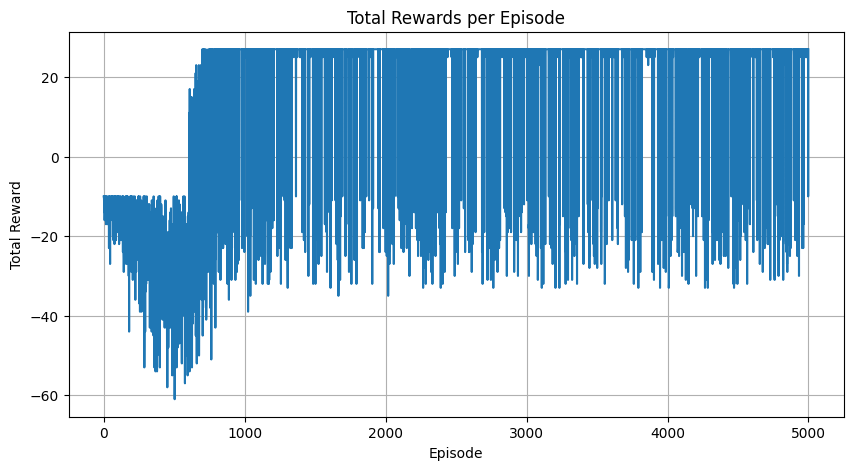

In [37]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title('Total Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    plt.show()


plot_rewards(rewards_all_episodes)

### Temporal Difference Learning (TD)

Reference: https://www.geeksforgeeks.org/deep-learning/temporal-difference-td-learning/


Temporal Difference (TD) learning is a reinforcement learning method that combines ideas from Monte Carlo methods and dynamic programming. It allows an agent to learn directly from raw experience without needing a model of the environment's dynamics. TD learning updates the value estimates based on the difference between the predicted value and the actual reward received, which is known as the temporal difference error. The TD learning update rule is given by:

`V(state) = V(state) + alpha * (reward + gamma * V(next_state) - V(state))`

Where:
- `V(state)` is the current value estimate for the given state.
- `alpha` is the learning rate, which determines how much the value estimates are updated based on new information.
- `reward` is the immediate reward received after taking the action in the current state.
- `gamma` is the discount factor, which determines the importance of future rewards.
- `V(next_state)` is the value estimate for the next state, representing the expected future reward from that state.

In [38]:
import numpy as np

# Example
states = ['A', 'B', 'C', 'D', 'E']
V = {s: 0.0 for s in states}  # Initialize value function
alpha = 0.1   # Learning rate
gamma = 0.9   # Discount factor

# Simulated experience: (current_state, reward, next_state)
experience = [
    ('B', 0, 'C'),
    ('C', 0, 'D'),
    ('D', 1, 'E'),  # Terminal state E with reward 1
]

for s, r, s_next in experience:
    V[s] = V[s] + alpha * (r + gamma * V[s_next] - V[s])

print(V)

{'A': 0.0, 'B': 0.0, 'C': 0.0, 'D': 0.1, 'E': 0.0}


## SARSA (State-Action-Reward-State-Action) 

Reference: https://www.geeksforgeeks.org/machine-learning/q-learning-in-python/

SARSA is another reinforcement learning algorithm that is similar to Q-learning but updates the Q-values based on the action taken in the next state rather than the maximum Q-value of the next state. The update rule for SARSA is as follows:
`Q(state, action) = Q(state, action) + alpha * (reward + gamma * Q(next_state, next_action) - Q(state, action))`

Where:
- `Q(state, action)` is the current Q-value for the given state and action.
- `alpha` is the learning rate, which determines how much the Q-values are updated based on new information.
- `reward` is the immediate reward received after taking the action in the current state.
- `gamma` is the discount factor, which determines the importance of future rewards.
- `Q(next_state, next_action)` is the Q-value for the next state and the action taken in that state, representing the expected future reward from that state-action pair.   

In [39]:
import numpy as np
import random


class GridWorld:
    def __init__(self, width, height, start, goal, obstacles):
        self.width = width
        self.height = height
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        self.state = start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state
        if action == 0:
            x = max(x - 1, 0)
        elif action == 1:
            x = min(x + 1, self.height - 1)
        elif action == 2:
            y = max(y - 1, 0)
        elif action == 3:
            y = min(y + 1, self.width - 1)

        next_state = (x, y)

        if next_state in self.obstacles:
            reward = -10
            done = True
        elif next_state == self.goal:
            reward = 10
            done = True
        else:
            reward = -1
            done = False

        self.state = next_state
        return next_state, reward, done

The agent uses the SARSA algorithm to update its Q-values based on its interactions with the environment, adjusting its behavior over time to reach the goal.

In [40]:
def sarsa(env, episodes, alpha, gamma, epsilon):
    Q = np.zeros((env.height, env.width, 4))

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon)
        done = False

        while not done:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon)

            Q[state[0], state[1], action] += alpha * \
                (reward + gamma * Q[next_state[0], next_state[1],
                 next_action] - Q[state[0], state[1], action])

            state = next_state
            action = next_action

    return Q

The epsilon-greedy policy balances exploration and exploitation. 
- With a probability of epsilon, the agent will explore the environment by selecting a random action, allowing it to discover new states and potentially better rewards. 
- With a probability of 1-epsilon, the agent will exploit its learned knowledge by selecting the action with the highest Q-value for the current state, which is expected to yield the best reward based on past experience. 

This strategy helps the agent to learn effectively while also ensuring that it continues to explore the environment to find optimal solutions.

In [41]:
def epsilon_greedy_policy(Q, state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, 3)
    else:
        return np.argmax(Q[state[0], state[1]])

Setting Up the Environment and Running SARSA
To set up the environment and run the SARSA algorithm, we can follow these steps:
1. Define the maze environment as a grid, where each cell represents a state. The agent can move in four directions: up, down, left, and right. We can represent the maze as a 2D array, where walls are represented by a specific value (e.g., -1), the exit is represented by another value (e.g., 1), and open paths are represented by 0.
2. Initialize the Q-table as a matrix of zeros, where rows represent states and columns represent actions (up, down, left, right).
3. Define the parameters for the SARSA algorithm, including the learning rate (alpha), discount factor (gamma), exploration rate (epsilon), and the rewards for different actions (e.g., reward for moving closer to the exit, reward for reaching the exit, and penalty for moving away from the exit).
4. Implement a helper function to check the validity of the agent's intended move and to select actions based on the epsilon-g  

In [42]:
width = 5
height = 5
start = (0, 0)
goal = (4, 4)
obstacles = [(2, 2), (3, 2)]
env = GridWorld(width, height, start, goal, obstacles)

episodes = 1000
alpha = 0.1
gamma = 0.99
epsilon = 0.1

Q = sarsa(env, episodes, alpha, gamma, epsilon)
print("Learned Q-values:", Q)

Learned Q-values: [[[-1.23200389 -0.24851814 -1.40846588 -0.45204764]
  [ 0.01350268  0.63572395 -1.87486234  1.88221221]
  [-0.89818032  3.45907122 -1.69444714 -1.91048507]
  [-1.41962487  3.96437049 -1.34724254 -1.27370178]
  [-1.03849489  4.07285112  0.05005791 -0.59808084]]

 [[-2.60999528 -2.89080431 -1.98223982  0.04506102]
  [ 0.15741391 -1.7646636  -0.95306342 -0.49930632]
  [ 1.07329712 -9.65663162  0.93825135  4.76408262]
  [ 1.124778    3.42151036  2.05518527  5.79224816]
  [ 0.40052798  6.96747885  3.87996635  5.28875182]]

 [[-2.19976755 -2.21822473 -2.384784   -1.66886946]
  [-1.81868229  0.45174602 -1.97898909 -2.71      ]
  [ 0.          0.          0.          0.        ]
  [-0.35154202  1.0368849  -1.          7.32333296]
  [ 4.64946183  7.7626916   5.00683692  6.73799999]]

 [[-1.67240339 -1.61538199 -1.61574748 -1.02414514]
  [-1.23377184  2.38390166 -1.61406336 -2.71      ]
  [ 0.          0.          0.          0.        ]
  [-0.18107991 -0.1        -1.9         

### Q-Learning

Reference: https://www.geeksforgeeks.org/machine-learning/q-learning-in-python/

Q-learning is a model-free reinforcement learning algorithm that seeks to find the best action to take given the current state of the environment. It does this by learning a Q-table, which is a matrix that stores the expected future rewards for taking each action in each state. The Q-values are updated based on the rewards received from the environment, allowing the agent to learn the optimal policy over time. The update rule for Q-learning is given by:
`Q(state, action) = Q(state, action) + alpha * (reward + gamma * max(Q(next_state)) - Q(state, action))`    

Where:
- `Q(state, action)` is the current Q-value for the given state and action.
- `alpha` is the learning rate, which determines how much the Q-values are updated based on new information.
- `reward` is the immediate reward received after taking the action in the current state.
- `gamma` is the discount factor, which determines the importance of future rewards.
- `max(Q(next_state))` is the maximum Q-value for the next state, representing the best possible future reward from that state.

Define the environment and initialize the Q-table. The environment can be represented as a grid (maze) where the agent can move in four directions: up, down, left, and right. The Q-table is initialized as a matrix of zeros, where rows represent states and columns represent actions. The agent will learn to navigate the maze by updating the Q-table based on the rewards received from taking actions in different states of the maze.

In [43]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 16         
n_actions = 4          
goal_state = 15        

Q_table = np.zeros((n_states, n_actions))

Set key hyperparameters such as `learning_rate` (alpha), `discount_factor` (gamma), `exploration_rate` (epsilon), and `epochs` to control the learning process of the agent. 

The `learning_rate` determines how much the Q-values are updated based on new information, while the `discount_factor` determines the importance of future rewards. 

The `exploration_rate` is used for epsilon-greedy action selection, which allows the agent to balance exploration and exploitation. 

The `epochs` parameter specifies how many times the agent will interact with the environment during training.

In [44]:
learning_rate = 0.8
discount_factor = 0.95
exploration_prob = 0.2
epochs = 1000

Define the State Transition Function:

- 0 for left
- 1 for right
- 2 for up
- 3 for down

In [45]:
def get_next_state(state, action):
    row, col = divmod(state, 4)  

    if action == 0 and col > 0:        
        col -= 1
    elif action == 1 and col < 3:      
        col += 1
    elif action == 2 and row > 0:     
        row -= 1
    elif action == 3 and row < 3:     
        row += 1

    return row * 4 + col

Implement the Q-Learning Algorithm. At each step:
1. The agent selects an action using the epsilon-greedy policy.
2. The agent takes the action and observes the new state and reward.
3. The agent updates the Q-table using the Q-learning update rule.
4. The agent continues this process until it reaches the exit or the maximum number of steps is reached.

In [46]:
for epoch in range(epochs):
    current_state = np.random.randint(0, n_states)  

    while True:
        if np.random.rand() < exploration_prob:
            action = np.random.randint(0, n_actions)
        else:
            action = np.argmax(Q_table[current_state])

        next_state = get_next_state(current_state, action)

        reward = 1 if next_state == goal_state else 0

        Q_table[current_state, action] += learning_rate * (
            reward + discount_factor * np.max(Q_table[next_state]) - Q_table[current_state, action]
        )

        if next_state == goal_state:
            break

        current_state = next_state

After training the agent using the Q-learning algorithm, we can output the learned Q-table, which contains the expected future rewards for taking each action in each state of the maze. The Q-table will have rows representing states and columns representing actions (up, down, left, right). The values in the Q-table will indicate the expected reward for taking a specific action in a given state, allowing us to understand the agent's learned policy for navigating the maze.

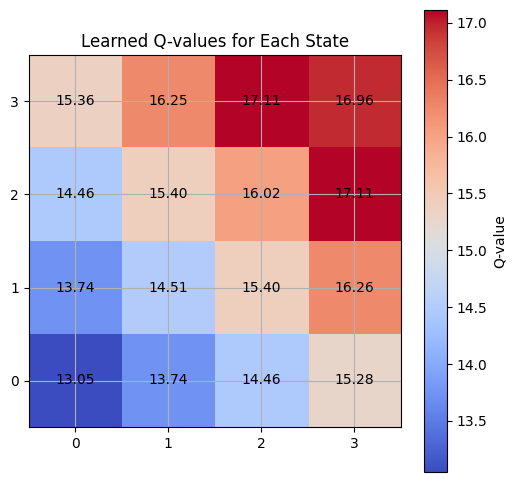

Learned Q-table:
[[11.01455444 12.18202383  5.7857721  13.05049641]
 [11.49783848 13.739049   12.63373879  9.64941218]
 [11.86940482 14.46216523 13.23466714 14.436549  ]
 [13.70733734 14.44024874 13.71004163 15.28122199]
 [12.66089516 13.43804254 12.18056154 13.73904715]
 [12.25759321 12.84559989 11.71674698 14.50613425]
 [12.79273323 15.4033933  13.16120409 15.06266273]
 [14.57527181 15.21239777 14.46170133 16.2563301 ]
 [11.79814456 14.41792883 13.03492763 14.46216523]
 [13.73773036 14.80283054 12.11657822 15.40070723]
 [13.67011546 16.02455981 12.73486692 15.92543512]
 [15.2058804  16.02382074 15.22268688 17.11350052]
 [14.44799587 15.35995261 13.61605451 14.41168115]
 [14.44759299 16.25463361 14.41958301 15.35853899]
 [14.71615989 17.11346331 15.17667529 15.88813488]
 [14.92230465 13.6529426  14.57910834 16.96158928]]


In [47]:
q_values_grid = np.max(Q_table, axis=1).reshape((4, 4))

plt.figure(figsize=(6, 6))
plt.imshow(q_values_grid, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Q-value')
plt.title('Learned Q-values for Each State')
plt.xticks(np.arange(4), ['0', '1', '2', '3'])
plt.yticks(np.arange(4), ['0', '1', '2', '3'])
plt.gca().invert_yaxis()
plt.grid(True)

for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{q_values_grid[i, j]:.2f}', ha='center', va='center', color='black')

plt.show()

print("Learned Q-table:")
print(Q_table)

- Each row index represents a state in the maze, and each column index represents an action (up, down, left, right). The values in the Q-table indicate the expected future rewards for taking each action in each state, which helps the agent to make informed decisions about which actions to take in different states of the maze.
- In the last few rows of the Q-table, we can see that the agent has learned to assign higher Q-values to actions that lead it closer to the exit, while actions that lead it away from the exit have lower Q-values. This indicates that the agent has successfully learned an optimal policy for navigating the maze and reaching the exit efficiently.
- The top rows of the Q-table may have lower Q-values for actions that lead to walls or out-of-bounds areas, while the rows corresponding to states closer to the exit will have higher Q-values for actions that move the agent towards the exit. This pattern in the Q-table reflects the agent's learning process and its ability to navigate the maze effectively.
- The agent’s policy or best action from each state would be the action corresponding to the maximum Q-value in that row.